# Character Network

Build an undirected network from `characters_enriched.csv`, using the `affiliated` column as the edge source. An edge is created between character *A* and character *B* iff *B* appears in *A*'s `affiliated` list **and** *B* is itself a character in the dataset (i.e. has a matching `ID`).

The graph is then explored interactively with [`netwulf`](https://netwulf.readthedocs.io/).

In [156]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm
import netwulf as nw

## 1. Load the enriched dataset

In [157]:
df = pd.read_csv('characters_enriched.csv')
print(f'{len(df)} characters loaded')
df.head()

3690 characters loaded


,name,ID,father,mother,spouse,lover,issue,allegiance,affiliated
0,A certain man,A_certain_man,NaN,NaN,NaN,NaN,NaN,NaN,Varys;Tyrion_Lannister;Stannis_Baratheon;Cortn...
1,Abelar Hightower,Abelar_Hightower,NaN,NaN,NaN,NaN,NaN,House_Hightower,Valarr_Targaryen;Daeron_II_Targaryen;Duncan_th...
2,Abelon,Abelon,NaN,NaN,NaN,NaN,NaN,Citadel,NaN
3,Addam of Duskendale,Addam_of_Duskendale,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Addam Frey,Addam_Frey,NaN,NaN,NaN,NaN,NaN,House_Frey,Aerys_I_Targaryen;Lord_Frey;Ambrose_Butterwell...


In [158]:
valid_ids = set(df['ID'].dropna().astype(str))
print(f'{len(valid_ids)} unique character IDs')

3690 unique character IDs


## 2. Build the edge set

`affiliated` is a `;`-separated list of character IDs. We iterate over every row, split the list and keep only targets whose ID also exists in the dataset. Using a `set` of `frozenset({a, b})` makes the graph undirected and deduplicates `A -> B` / `B -> A` automatically.

In [159]:
edges = set()

for row in tqdm(df.itertuples(index=False), total=len(df), desc='Building edges'):
    source = row.ID
    if not isinstance(source, str) or source not in valid_ids:
        continue
    affiliated = row.affiliated
    if not isinstance(affiliated, str) or not affiliated.strip():
        continue
    for target in affiliated.split(';'):
        target = target.strip()
        if not target or target == source:
            continue
        if target in valid_ids:
            edges.add(frozenset((source, target)))

print(f'{len(edges)} unique undirected edges')

Building edges: 100%|██████████| 3690/3690 [00:00<00:00, 23952.28it/s]

36315 unique undirected edges


## 3. Build the graph

All character IDs are added as nodes first (so isolates are retained), then the edges are added. Node attributes (`name`, `allegiance`) are attached for tooltips / styling.

In [160]:
G = nx.Graph()

for row in tqdm(df.itertuples(index=False), total=len(df), desc='Adding nodes'):
    if not isinstance(row.ID, str):
        continue
    G.add_node(
        row.ID,
        name=row.name if isinstance(row.name, str) else row.ID,
        allegiance=row.allegiance if isinstance(row.allegiance, str) else '',
    )

for edge in tqdm(edges, desc='Adding edges'):
    a, b = tuple(edge)
    G.add_edge(a, b)

print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

Adding edges: 100%|██████████| 36315/36315 [00:00<00:00, 1117621.40it/s]

Graph: 3690 nodes, 36315 edges


## 4. Basic network stats

In [161]:
n, m = G.number_of_nodes(), G.number_of_edges()
density = nx.density(G)
isolates = sum(1 for _, d in G.degree() if d == 0)

print(f'Nodes:    {n}')
print(f'Edges:    {m}')
print(f'Density:  {density:.6f}')
print(f'Isolates: {isolates}')

Nodes:    3690
Edges:    36315
Density:  0.005336
Isolates: 154


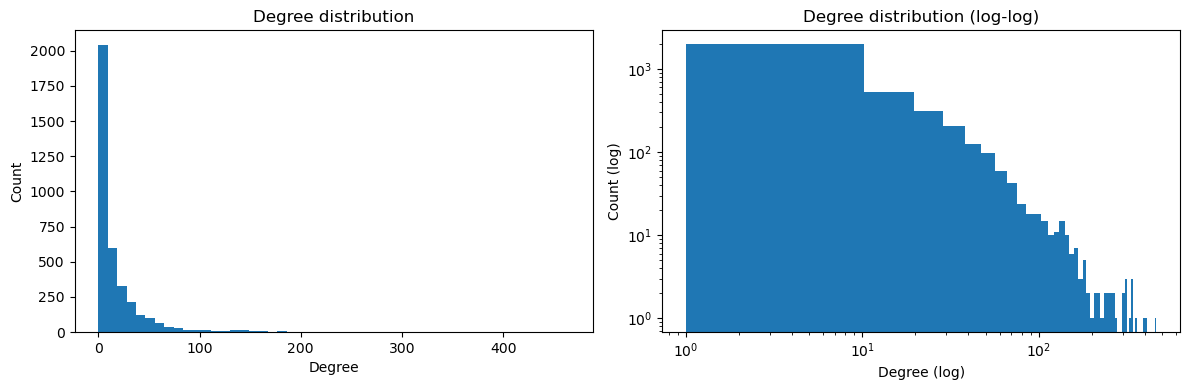

In [162]:
degrees = [d for _, d in G.degree()]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(degrees, bins=50)
ax[0].set_xlabel('Degree')
ax[0].set_ylabel('Count')
ax[0].set_title('Degree distribution')

ax[1].hist([d for d in degrees if d > 0], bins=50)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel('Degree (log)')
ax[1].set_ylabel('Count (log)')
ax[1].set_title('Degree distribution (log-log)')
plt.tight_layout()
plt.show()

In [163]:
top = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:20]
pd.DataFrame(
    [(G.nodes[i].get('name', i), d, G.nodes[i].get('allegiance', '')) for i, d in top],
    columns=['name', 'degree', 'allegiance'],
)

,name,degree,allegiance
0,Tyrion Lannister,465,House_Lannister;Second_Sons
1,Jaime Lannister,409,House_Lannister;Kingsguard
2,Stannis Baratheon,391,
3,Tywin Lannister,356,House_Lannister
4,Eddard Stark,344,House_Stark
5,Cersei Lannister,342,House_Lannister;House_Baratheon_of_King's_Landing
6,Joffrey Baratheon,336,
7,Jon Snow,331,House_Stark;Night's_Watch
8,Robb Stark,312,
9,Jaehaerys I Targaryen,311,


## 5. Largest connected component

The full graph is too big for a responsive netwulf session, so we restrict the visualization to the LCC.

In [164]:
components = list(nx.connected_components(G))
print(f'{len(components)} connected components')

largest_cc = max(components, key=len)
LCC = G.subgraph(largest_cc).copy()

print(f'Full graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'LCC:        {LCC.number_of_nodes()} nodes, {LCC.number_of_edges()} edges')
print(f'LCC covers  {LCC.number_of_nodes() / G.number_of_nodes():.1%} of all nodes')

173 connected components
Full graph: 3690 nodes, 36315 edges
LCC:        3485 nodes, 36273 edges
LCC covers  94.4% of all nodes


## 6. Interactive visualization with netwulf

Node `size` is scaled by degree and `label` is set for the top-degree characters so the hubs are easy to spot. Closing the netwulf browser tab returns `network` and `config` for further use.

In [165]:
max_degree = max(d for _, d in LCC.degree())
for node, d in tqdm(LCC.degree(), total=LCC.number_of_nodes(), desc='Node attributes'):
    LCC.nodes[node]['degree'] = d
    LCC.nodes[node]['size'] = d / max_degree * 50

top_n = 25
top_nodes = sorted(LCC.nodes(), key=lambda n: LCC.nodes[n]['degree'], reverse=True)[:top_n]
for node in LCC.nodes():
    LCC.nodes[node]['label'] = LCC.nodes[node].get('name', node) if node in top_nodes else ''

Node attributes: 100%|██████████| 3485/3485 [00:00<00:00, 1318642.26it/s]


In [166]:
network, config = nw.visualize(LCC, config={
    'node_size': 10,
    'node_charge': -50,
    'link_distance': 10,
    'link_width': 0.5,
    'node_size_variation': 1.0,
    'display_node_labels': True,
    'min_link_weight_percentile': 0,
    'max_link_weight_percentile': 1,
})

/opt/homebrew/Caskroom/miniconda/base/envs/new_base/lib/python3.11/site-packages/networkx/readwrite/json_graph/node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


## 7. Color nodes by primary allegiance

Each character's first allegiance (before the first `;`) is taken as their "primary" house. The **top 15 houses by frequency** each get a distinct color; everyone else is grey, and characters without an allegiance are light grey.

In [167]:
from collections import Counter
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def primary_allegiance(val):
    if not isinstance(val, str) or not val.strip():
        return None
    return val.split(';')[0].strip()

primary = {n: primary_allegiance(a) for n, a in nx.get_node_attributes(LCC, 'allegiance').items()}

top_houses = [h for h, _ in Counter(p for p in primary.values() if p).most_common(15)]
palette = [mcolors.to_hex(cm.tab20(i)) for i in range(len(top_houses))]
house_color = dict(zip(top_houses, palette))

# Manual overrides so distinct houses don't end up with near-grey tab20 slots
house_color['House_Baratheon'] = '#f5c518'  # canonical Baratheon gold

OTHER, NONE = '#888888', '#dddddd'
for node in LCC.nodes():
    p = primary.get(node)
    if p is None:
        c = NONE
    elif p in house_color:
        c = house_color[p]
    else:
        c = OTHER
    LCC.nodes[node]['color'] = c
    LCC.nodes[node]['group'] = p if p in house_color else ('Other' if p else 'None')

pd.DataFrame([(h, Counter(primary.values())[h], house_color[h]) for h in top_houses],
             columns=['house', 'count', 'color'])

,house,count,color
0,Citadel,123,#1f77b4
1,House_Frey,111,#aec7e8
2,Night's_Watch,110,#ff7f0e
3,House_Targaryen,105,#ffbb78
4,House_Stark,105,#2ca02c
5,Faith_of_the_Seven,75,#98df8a
6,House_Lannister,69,#d62728
7,House_Greyjoy,66,#ff9896
8,Mance_Rayder,54,#9467bd
9,House_Tyrell,50,#c5b0d5


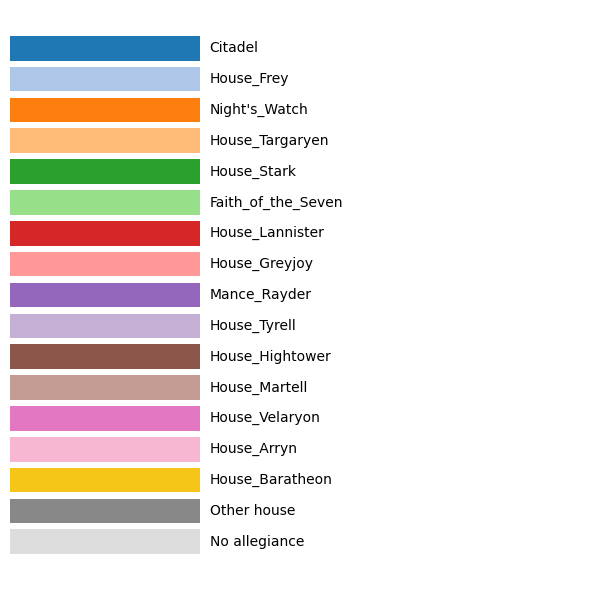

In [168]:
# Simple legend so you know which color is which house
fig, ax = plt.subplots(figsize=(6, 6))
for i, h in enumerate(top_houses):
    ax.barh(i, 1, color=house_color[h])
    ax.text(1.05, i, h, va='center')
ax.barh(len(top_houses), 1, color=OTHER); ax.text(1.05, len(top_houses), 'Other house', va='center')
ax.barh(len(top_houses) + 1, 1, color=NONE); ax.text(1.05, len(top_houses) + 1, 'No allegiance', va='center')
ax.set_xlim(0, 3); ax.invert_yaxis(); ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
network, config = nw.visualize(LCC, config={
    'zoom': 0.8,
    'node_charge': -45,
    'node_gravity': 0.1,
    'link_distance': 15,
    'link_distance_variation': 0,
    'node_collision': True,
    'wiggle_nodes': False,
    'freeze_nodes': False,
    'node_fill_color': '#79aaa0',
    'node_stroke_color': '#555555',
    'node_label_color': '#000000',
    'node_size': 20.8,
    'node_stroke_width': 1,
    'node_size_variation': 0.19,
    'display_node_labels': False,
    'scale_node_size_by_strength': False,
    'link_color': '#7c7c7c',
    'link_width': 2,
    'link_alpha': 0.07,
    'link_width_variation': 0.5,
    'display_singleton_nodes': True,
    'min_link_weight_percentile': 0,
    'max_link_weight_percentile': 1,
})

## 8. Export for the website

Save the graph so it can be downloaded from the site.

In [ ]:
nx.write_gexf(G, 'character_network.gexf')
nx.write_gexf(LCC, 'character_network_lcc.gexf')